In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")

from src.database.connection import get_connection

import warnings
warnings.filterwarnings(
    "ignore",
    message = "pandas only supports SQLAlchemy connectable.*",
    category = UserWarning
)

#### LOAD DATA

In [2]:
conn = get_connection()

query = """
    SELECT *
    FROM weather_eda
"""

weather = pd.read_sql(query, conn)
weather["forecast_time"] = pd.to_datetime(weather["forecast_time"], utc = True)

query = """
    SELECT 
        *
    FROM demand_eda;
"""

demand = pd.read_sql(query, conn)
demand["start_time"] = pd.to_datetime(demand["start_time"], utc = True)

conn.close()

weather.head()

,location_name,forecast_time,temperature_2m,relative_humidity_2m,apparent_temperature,snowfall,rain
0,Norwich,2023-08-01 00:00:00+00:00,15.52,85.0,14.06,0.0,0.0
1,Newcastle,2023-08-01 00:00:00+00:00,14.09,93.0,13.30,0.0,0.0
2,Inverness,2023-08-01 00:00:00+00:00,13.98,96.0,13.16,0.0,0.1
3,London,2023-08-01 00:00:00+00:00,15.19,87.0,13.69,0.0,0.0
4,Cardiff,2023-08-01 00:00:00+00:00,15.88,90.0,15.11,0.0,0.0


In [3]:
weather.describe()

,temperature_2m,relative_humidity_2m,apparent_temperature,snowfall,rain
count,210624.000000,210624.000000,210624.000000,210624.000000,210624.000000
mean,11.595999,76.290978,9.195323,0.000331,0.107210
std,5.694207,14.635476,6.741898,0.016180,0.466565
min,-6.830000,8.000000,-11.390000,0.000000,0.000000
25%,7.530000,67.000000,4.240000,0.000000,0.000000
50%,11.440000,79.000000,8.890000,0.000000,0.000000
75%,15.390000,88.000000,13.810000,0.000000,0.000000
max,37.669998,105.000000,38.930000,2.170000,23.799999


In [4]:
weather.groupby("location_name")["forecast_time"].diff().value_counts().sort_index()

forecast_time
0 days 01:00:00    210616
Name: count, dtype: int64

In [5]:
weather_conditions = {
    "temperature_2m": "Temperature", 
    "relative_humidity_2m": "Humidity", 
    "apparent_temperature": "Apparent Temperature", 
    "snowfall": "Snowfall", 
    "rain": "Rain"
}
weather.groupby("location_name")[list(weather_conditions.keys())].size()

location_name
Cardiff       26328
Edinburgh     26328
Inverness     26328
London        26328
Manchester    26328
Newcastle     26328
Norwich       26328
Plymouth      26328
dtype: int64

In [6]:
fill_demand = demand.copy()

fill_demand["previous_demand"] = fill_demand["true_demand_mw"].shift(1)
fill_demand["next_demand"] = fill_demand["true_demand_mw"].shift(-1)
fill_demand["previous_start_time"] = fill_demand["start_time"].shift(1)
fill_demand["interval"] = fill_demand["start_time"] - fill_demand["previous_start_time"]

wrong_intervals = fill_demand[fill_demand["interval"] == pd.Timedelta(hours = 1)].copy()
wrong_intervals["start_time"] = wrong_intervals["start_time"] - pd.Timedelta(minutes = 30)
wrong_intervals["true_demand_mw"] = ((
    wrong_intervals["previous_demand"] + wrong_intervals["next_demand"]
) / 2).round(0)

wrong_intervals = wrong_intervals[["start_time", "true_demand_mw"]]

demand = pd.concat([demand, wrong_intervals], ignore_index = True).sort_values("start_time")
demand = demand.rename(columns = {"start_time": "prediction_time"})

In [7]:
modelling = pd.merge_asof(
    left = demand,
    right = weather,
    left_on = "prediction_time",
    right_on = "forecast_time",
    direction = "backward"
)

modelling.head()

,prediction_time,true_demand_mw,location_name,forecast_time,temperature_2m,relative_humidity_2m,apparent_temperature,snowfall,rain
0,2023-08-01 00:00:00+00:00,17609.0,Manchester,2023-08-01 00:00:00+00:00,14.87,91.0,13.87,0.0,0.2
1,2023-08-01 00:30:00+00:00,17596.0,Manchester,2023-08-01 00:00:00+00:00,14.87,91.0,13.87,0.0,0.2
2,2023-08-01 01:00:00+00:00,17288.0,Plymouth,2023-08-01 01:00:00+00:00,15.57,85.0,14.12,0.0,0.0
3,2023-08-01 01:30:00+00:00,16797.0,Plymouth,2023-08-01 01:00:00+00:00,15.57,85.0,14.12,0.0,0.0
4,2023-08-01 02:00:00+00:00,16742.0,Norwich,2023-08-01 02:00:00+00:00,14.82,87.0,12.88,0.0,0.0


In [8]:
modelling["interval"] = modelling["prediction_time"] - modelling["forecast_time"]
modelling["interval"].value_counts()

interval
0 days 00:00:00    26304
0 days 00:30:00    26304
Name: count, dtype: int64

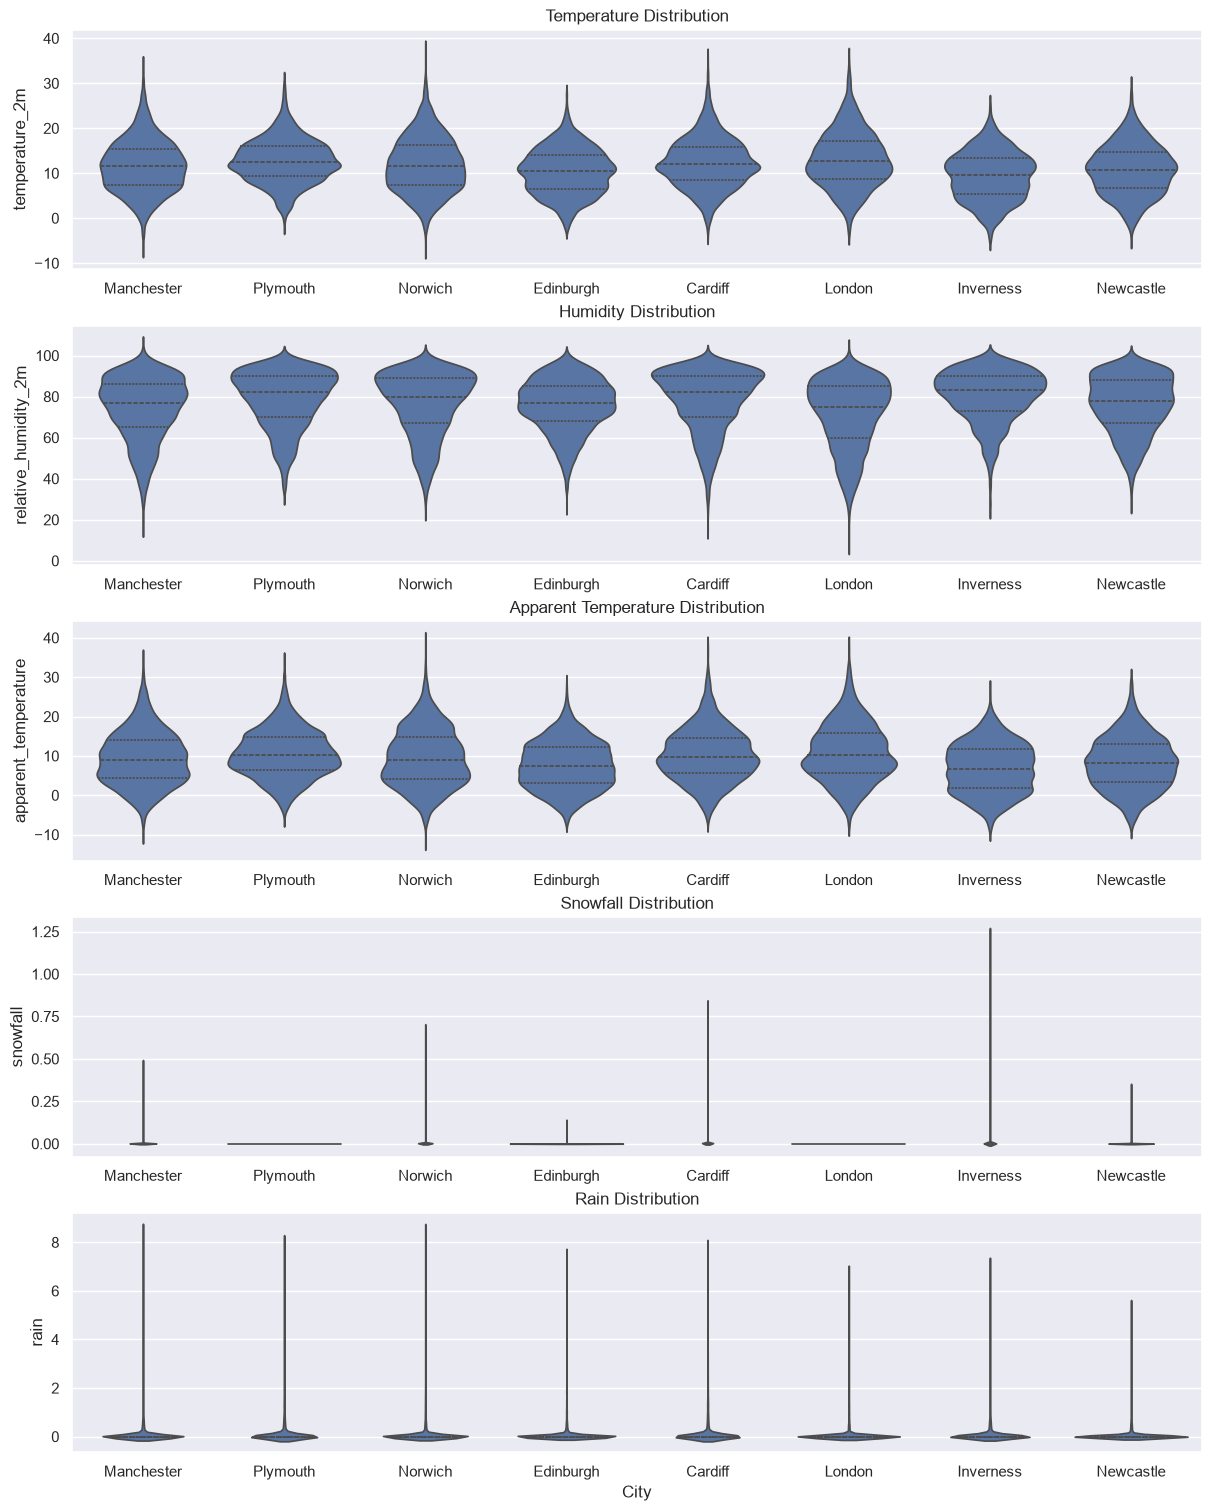

In [9]:
fig, axes = plt.subplots(5, 1, figsize = (12, 15), constrained_layout = True)
axes = axes.flatten()

for (weather_condition, label), ax in zip(weather_conditions.items(), axes):
    sns.violinplot(
        data = modelling,
        y = weather_condition,
        x = "location_name",
        ax = ax,
        inner = "quartile"
    )

    ax.set_title(f"{label} Distribution")
    ax.set_xlabel("")

axes[4].set_xlabel("City")

plt.show()

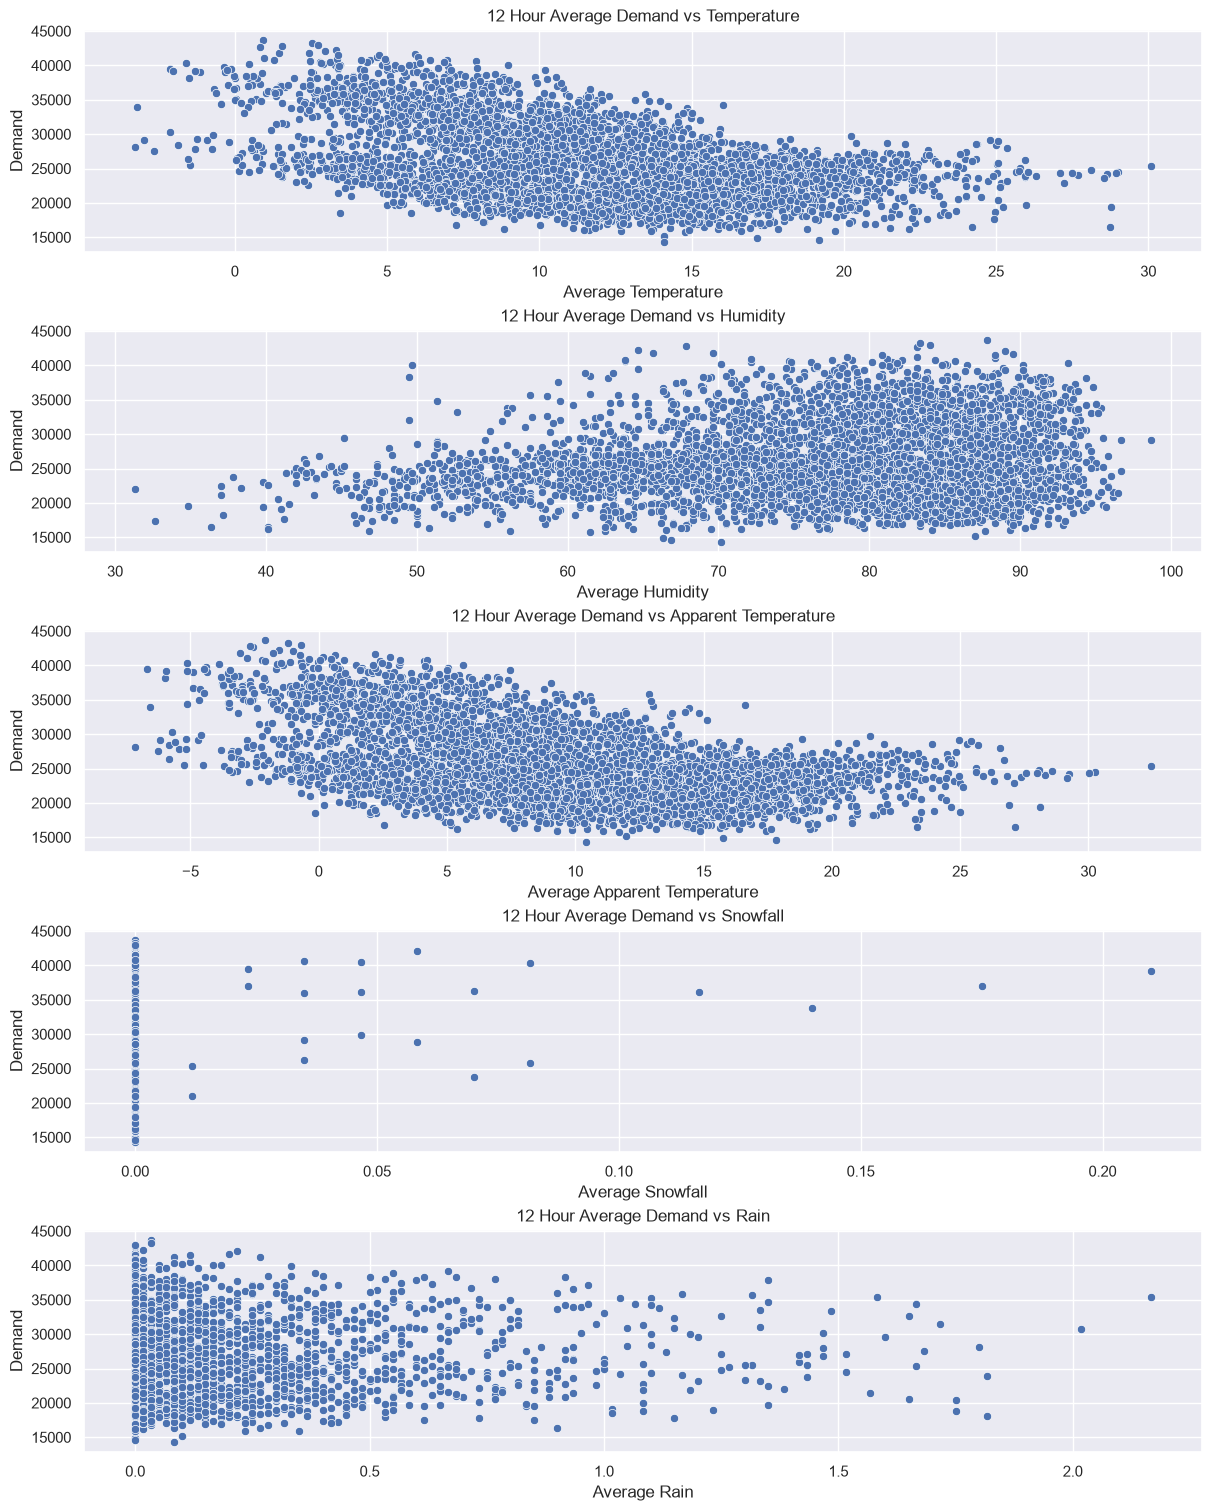

In [10]:
daily_model = modelling.set_index("forecast_time").resample("6h").agg({
    "true_demand_mw": "mean",
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "apparent_temperature": "mean",
    "snowfall": "mean",
    "rain": "mean"
}).reset_index()

fig, axes = plt.subplots(5, 1, figsize = (12, 15), constrained_layout = True)
axes = axes.flatten()

for (weather_condition, label), ax in zip(weather_conditions.items(), axes):
    sns.scatterplot(
        data = daily_model,
        x = weather_condition,
        y = "true_demand_mw",
        ax = ax
    )

    ax.set_title(f"12 Hour Average Demand vs {label}")
    ax.set_xlabel(f"Average {label}")
    ax.set_ylabel("Demand")

plt.show()

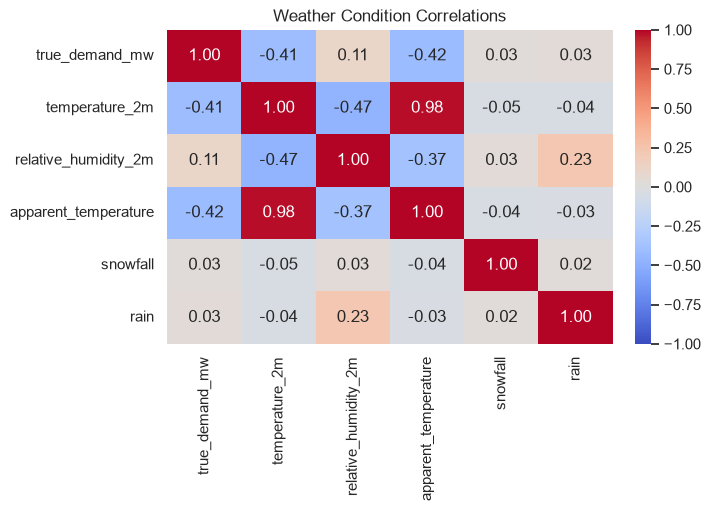

In [11]:
condition_correlations = modelling[["true_demand_mw"] + list(weather_conditions.keys())].corr()

plt.figure(figsize = (7, 5), constrained_layout = True)

sns.heatmap(
    data = condition_correlations,
    vmin = -1,
    cmap = "coolwarm",
    annot = True,
    fmt = ".2f"
)

plt.title("Weather Condition Correlations")

plt.show()

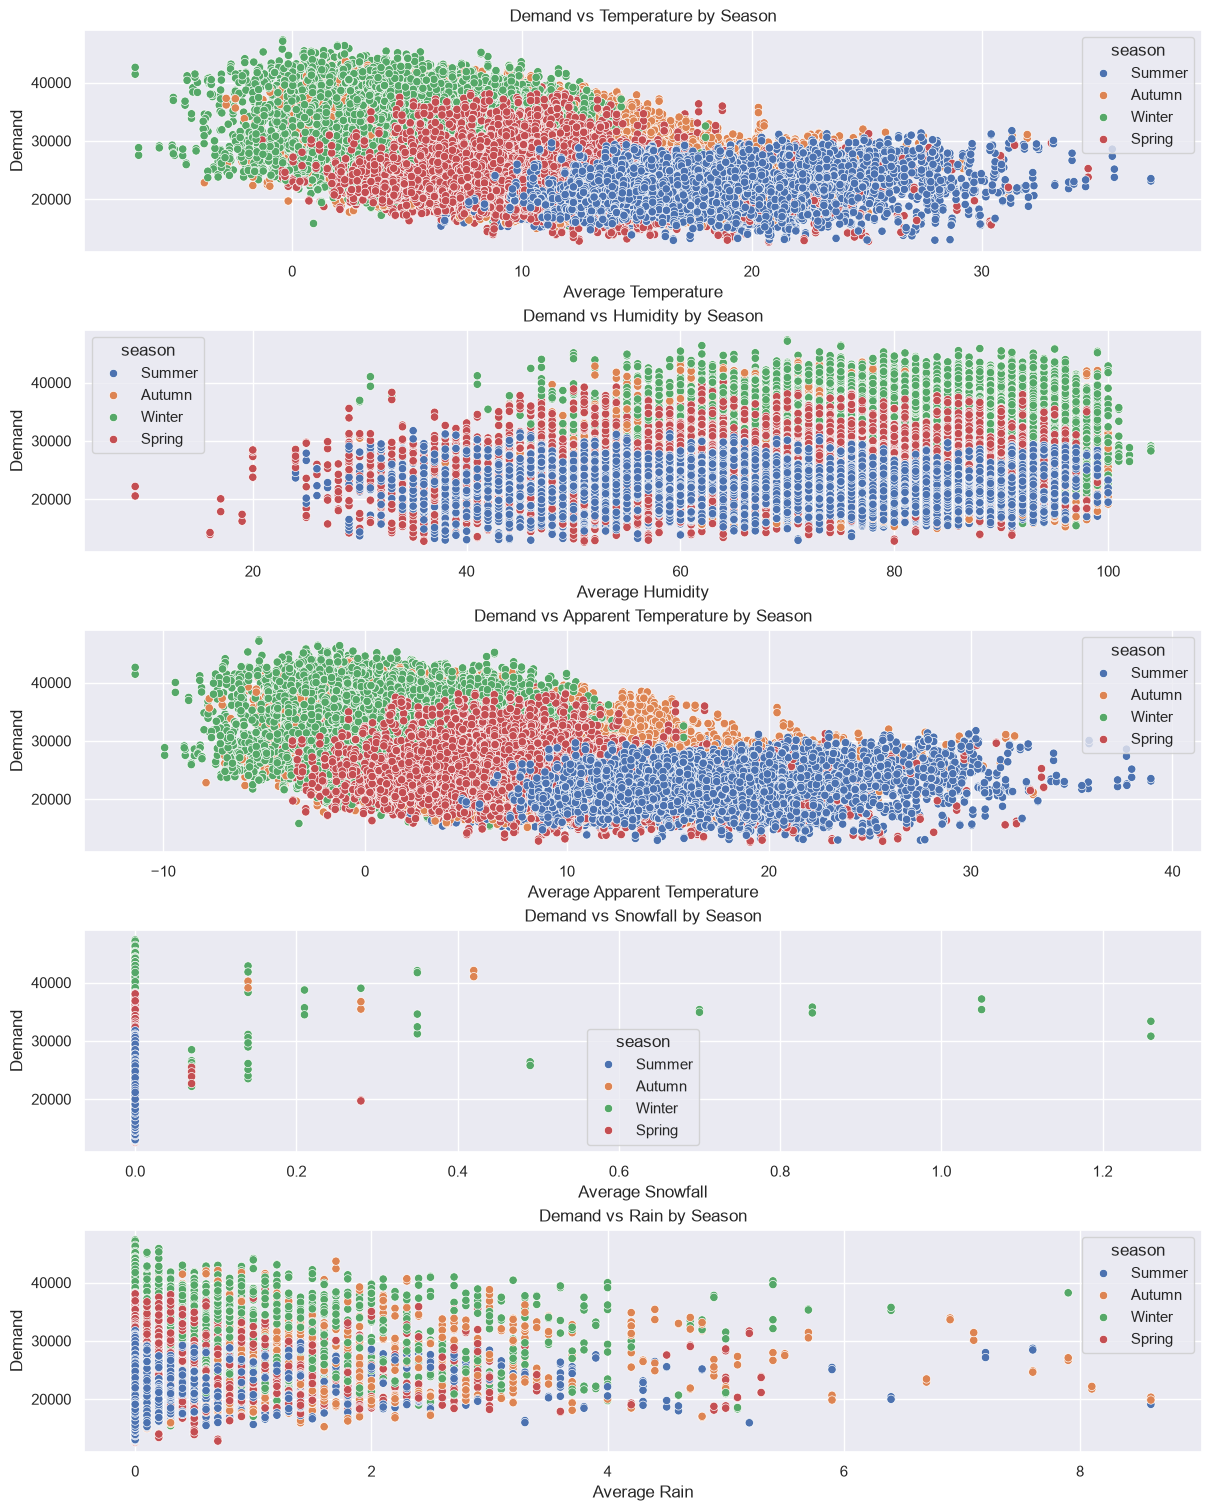

In [12]:
def months_to_seasons(month):
    if 3 <= month < 6:
        return "Spring"
    elif 6 <= month < 9:
        return "Summer"
    elif 9 <= month < 12:
        return "Autumn"
    else:
        return "Winter"

modelling["season"] = modelling["forecast_time"].dt.month.apply(months_to_seasons)

fig, axes = plt.subplots(5, 1, figsize = (12, 15), constrained_layout = True)
axes = axes.flatten()

for (weather_condition, label), ax in zip(weather_conditions.items(), axes):
    sns.scatterplot(
        data = modelling,
        x = weather_condition,
        y = "true_demand_mw",
        hue = "season",
        ax = ax
    )

    ax.set_title(f"Demand vs {label} by Season")
    ax.set_xlabel(f"Average {label}")
    ax.set_ylabel("Demand")

plt.show()

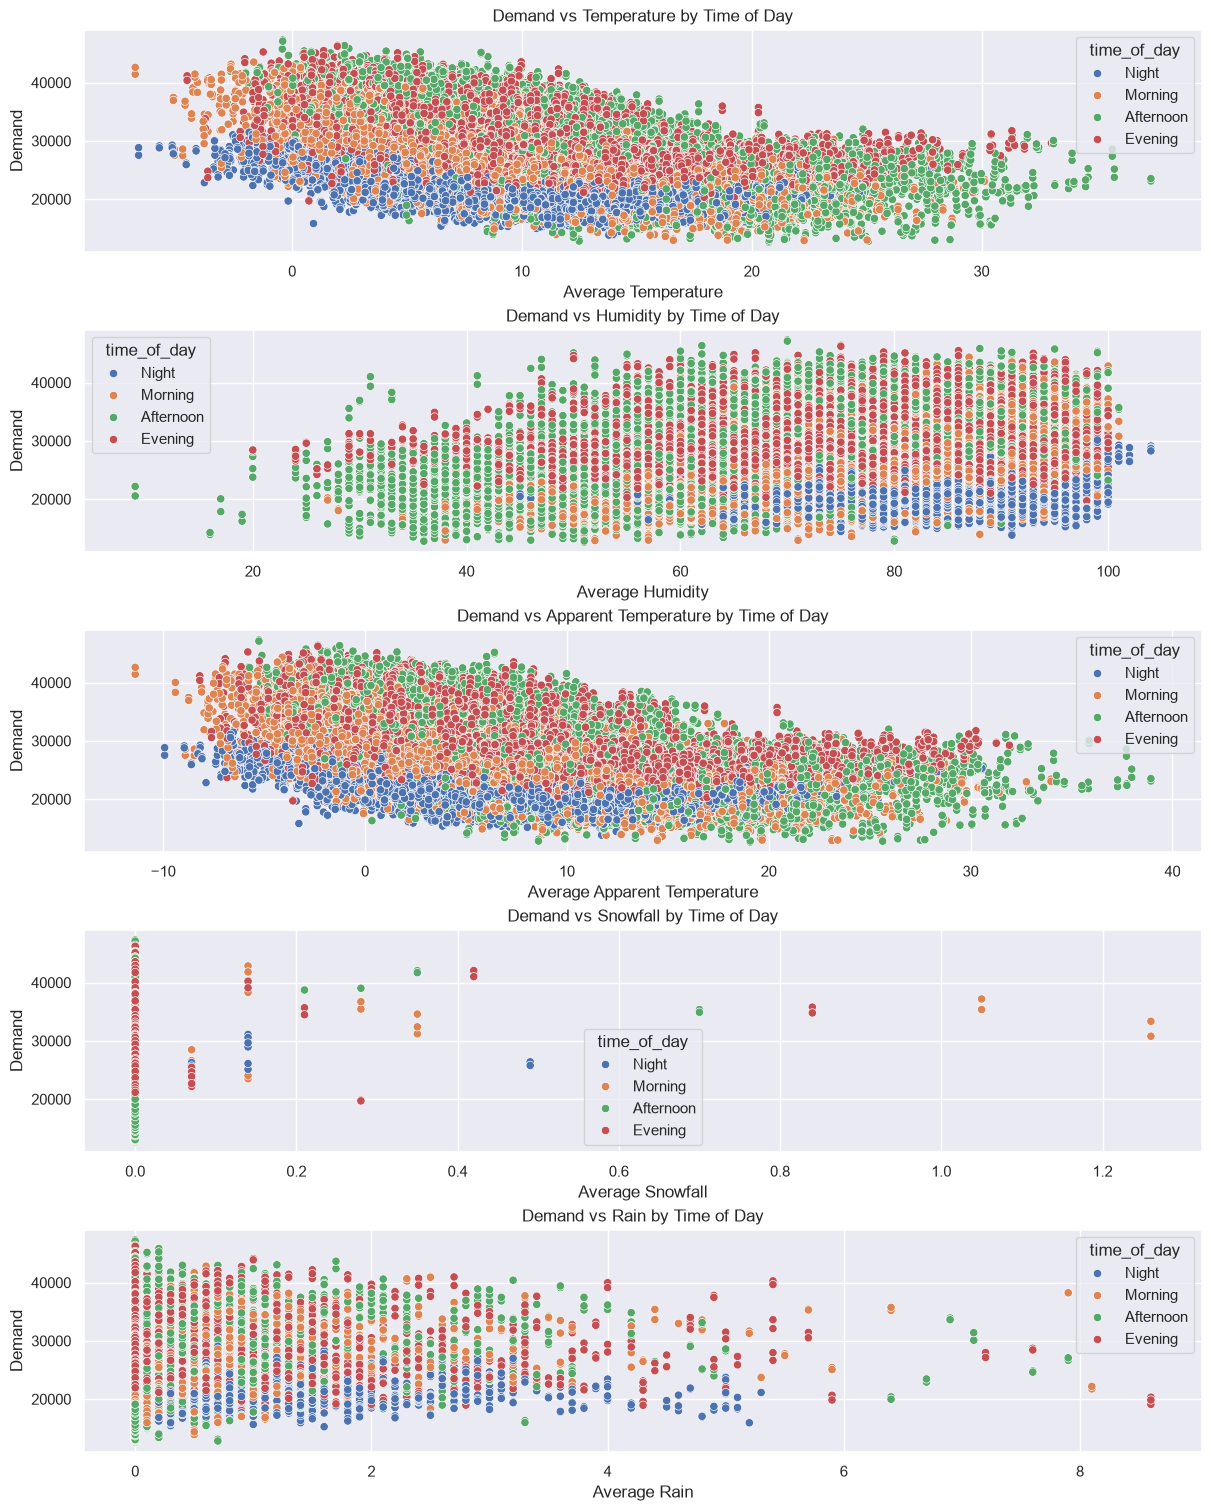

In [13]:
def hours_to_period(hour):
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

modelling["time_of_day"] = modelling["forecast_time"].dt.hour.apply(hours_to_period)

fig, axes = plt.subplots(5, 1, figsize = (12, 15), constrained_layout = True)
axes = axes.flatten()

for (weather_condition, label), ax in zip(weather_conditions.items(), axes):
    sns.scatterplot(
        data = modelling,
        x = weather_condition,
        y = "true_demand_mw",
        hue = "time_of_day",
        ax = ax
    )

    ax.set_title(f"Demand vs {label} by Time of Day")
    ax.set_xlabel(f"Average {label}")
    ax.set_ylabel("Demand")

plt.show()

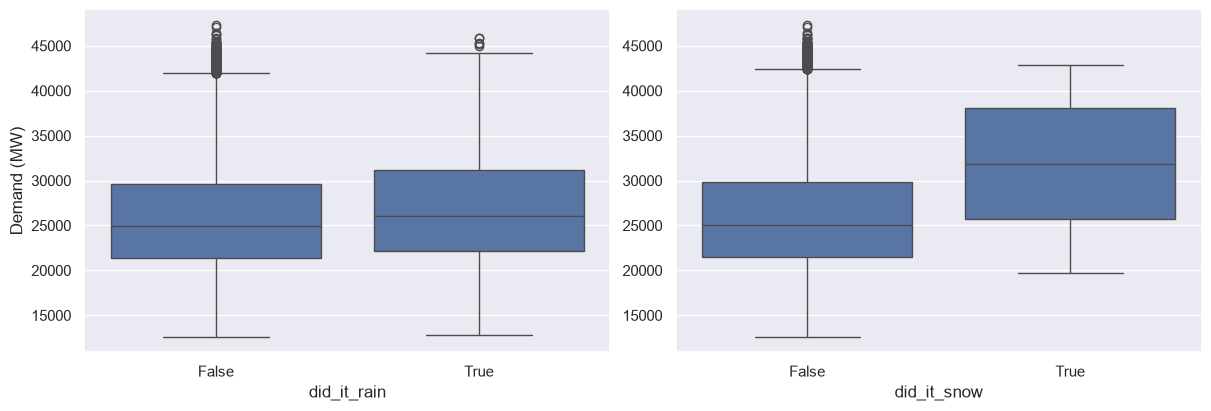

In [14]:
modelling["did_it_rain"] = modelling["rain"] > 0
modelling["did_it_snow"] = modelling["snowfall"] > 0

fig, axes = plt.subplots(1, 2, figsize = (12, 4), constrained_layout = True)
axes = axes.flatten()

for column, ax in zip(["did_it_rain", "did_it_snow"], axes):
    sns.boxplot(
        data = modelling,
        x = column,
        y = "true_demand_mw",
        ax = ax
    )

    ax.set_ylabel("")

axes[0].set_ylabel("Demand (MW)")

plt.show()

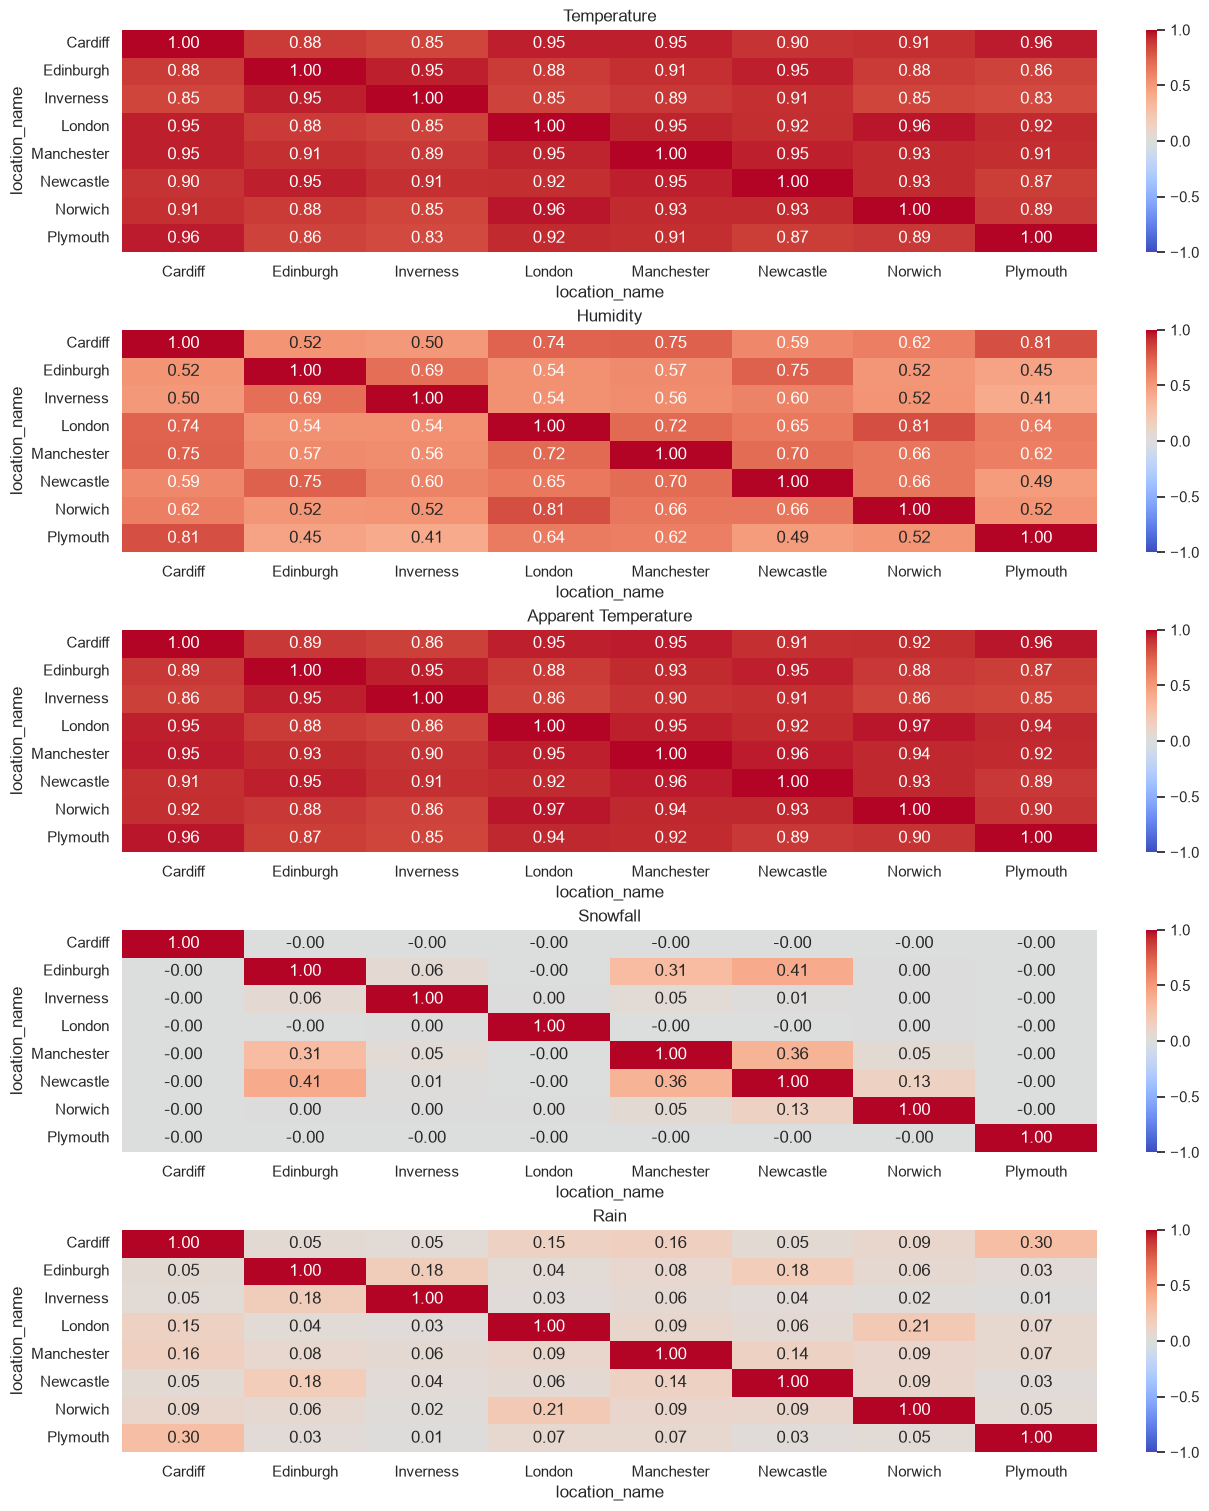

In [15]:
fig, axes = plt.subplots(5, 1, figsize = (12, 15), constrained_layout = True)
axes = axes.flatten()

for (weather_condition, label), ax in zip(weather_conditions.items(), axes):
    data_to_model = weather.pivot(
        index = "forecast_time",
        columns = "location_name",
        values = weather_condition
    )

    sns.heatmap(
        data = data_to_model.corr(),
        vmin = -1,
        cmap = "coolwarm",
        annot = True,
        fmt = ".2f",
        ax = ax
    )

    ax.set_title(f"{label}")

plt.show()